In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle


No protocol specified


# generate true Us

In [2]:
n_subs = 24
n_parcel = 32
n_voxels  = 40
n_tasks = 16

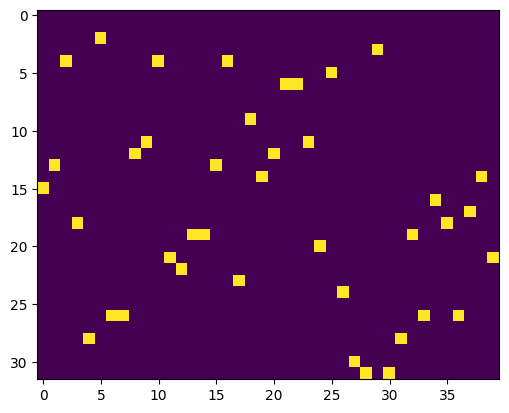

In [3]:
U_true = sim.generate_Us(s= n_subs, k = n_parcel, p = n_voxels, type= 'hard')
plt.imshow(U_true[2])

# Generate test data (random Vs)

In [4]:
V_test = sim.generate_Vs(n_tasks= n_tasks, n_parcel= n_parcel, Vs_type= 'random',noise_std= 0.0)
y_test = V_test @ U_true

In [7]:
def evaluate_U_MSE(D,Vs,ytest,vtest):
    for i, row in D.iterrows():
        task_subset_indices = row['combination']
        V_subset = Vs[task_subset_indices, :]
        
        # Subtract mean across rows
        V_subset = V_subset - np.mean(V_subset, axis=0)
        
        # Generate the data Y from U_true and V_subset
        y_subset = V_subset @ U_true

        # Estimate U_hat using OLS
        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        U_hat_NNLS = sim.estimate_Us_NNLS(y_subset, V_subset)
    

        # MSE between U_true and U_hat_ols
        D.at[i, 'OLS_MSE'] = sim.U_MSE(U_true, U_hat_ols)
        D.at[i, 'NNLS_MSE'] = sim.U_MSE(U_true, U_hat_NNLS)

        # make into tensores
        ytest = pt.tensor(ytest)
        vtest = pt.tensor(vtest)
        U_hat_ols = pt.tensor(U_hat_ols)
        U_hat_NNLS = pt.tensor(U_hat_NNLS)
        
        # calculate cosine error between ytest reconstrcuted and original
        cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().numpy()
        cos_nnls = ev.coserr(ytest,vtest,U_hat_NNLS).mean().numpy()


        D.at[i, 'cos_ols'] = cos_ols
        D.at[i, 'cos_nnls'] = cos_nnls

    return D



# Random V Library

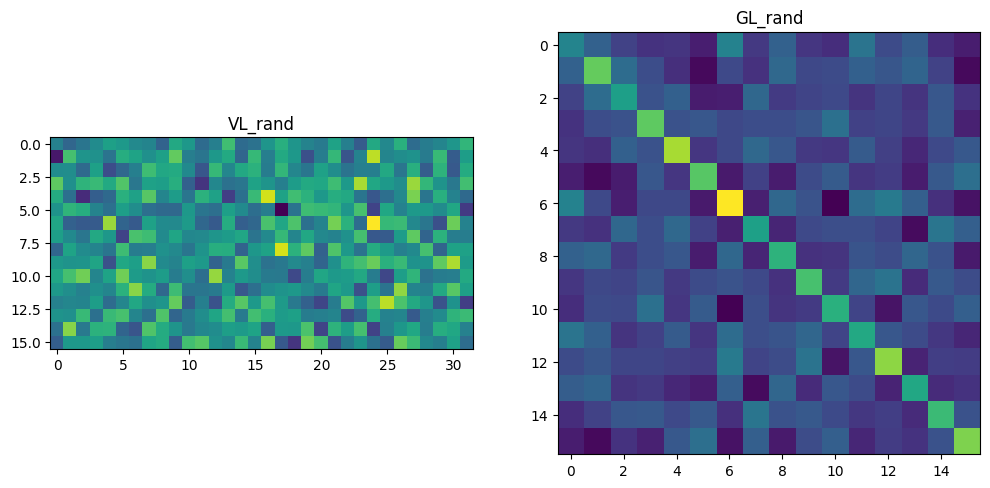

In [8]:
VL_rand = sim.generate_Vs(n_tasks= n_tasks, n_parcel= n_parcel, Vs_type= 'random',noise_std= 0.0)
GL_rand = VL_rand @ VL_rand.T

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_rand)
ax[0].set_title('VL_rand')

ax[1].imshow(GL_rand)
ax[1].set_title('GL_rand')

plt.show()


In [9]:
D_rand = ut.build_combinations(GL_rand, strategy='random',n_iter=200,n_tasks=8,seed=1)
D_rand = evaluate_U_MSE(D_rand, VL_rand, y_test, V_test)

A_rand = D_rand[D_rand['offset'] == 0.001]


/tmp/ipykernel_389191/1177335138.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest)
/tmp/ipykernel_389191/1177335138.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest)


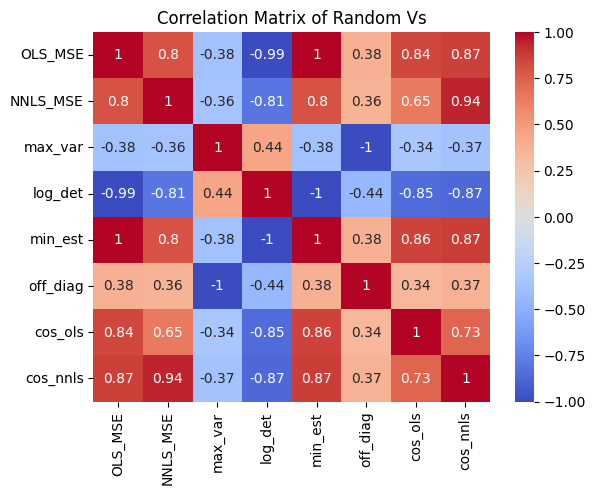

In [11]:
# Correlation heatmap
corr_matrix = A_rand[['OLS_MSE','NNLS_MSE' ,'max_var', 'log_det', 'min_est', 'off_diag','cos_ols','cos_nnls']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Random Vs')
plt.show()

# orthogonal V library

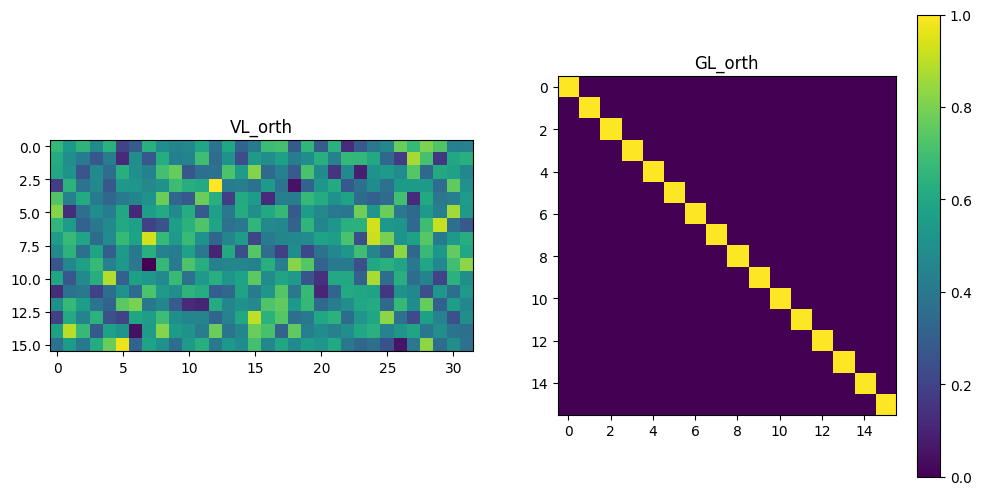

In [12]:
VL_orth = sim.generate_Vs(n_tasks= n_tasks, n_parcel= n_parcel, Vs_type= 'orthogonal',noise_std= 0.0)
GL_orth = VL_orth @ VL_orth.T

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_orth)
ax[0].set_title('VL_orth')

im2 = ax[1].imshow(GL_orth)
ax[1].set_title('GL_orth')
fig.colorbar(im2, ax=ax[1]) 

plt.show()

In [13]:
D_orth = ut.build_combinations(GL_orth, strategy='random',n_iter=200,n_tasks=8,seed=1)
D_orth = evaluate_U_MSE(D_orth, VL_orth, y_test, V_test)


A_orth = D_orth[D_orth['offset'] == 0.001]


/tmp/ipykernel_389191/1177335138.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest)
/tmp/ipykernel_389191/1177335138.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest)


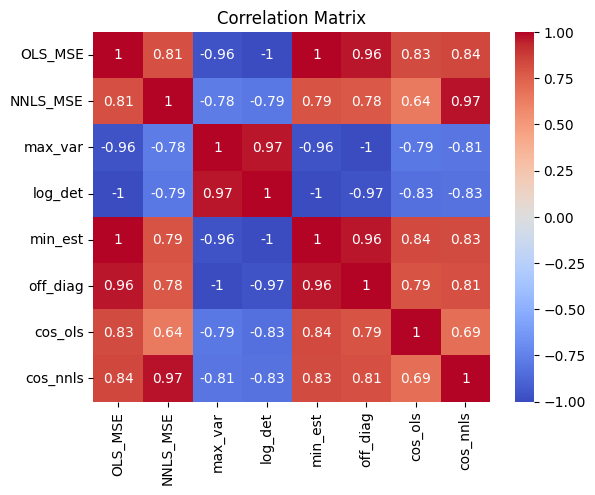

In [14]:
# Correlation heatmap
corr_matrix = A_orth[['OLS_MSE','NNLS_MSE', 'max_var', 'log_det', 'min_est', 'off_diag','cos_ols','cos_nnls']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# full correaltion

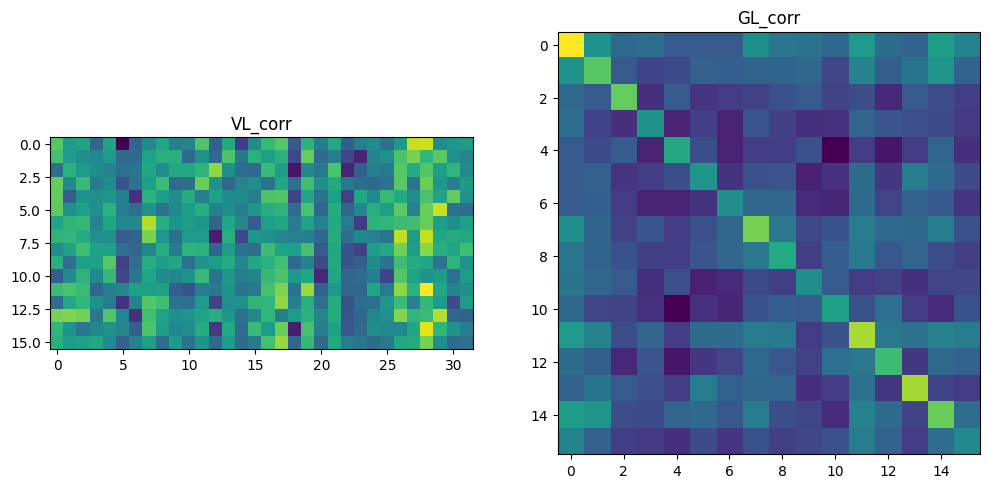

In [15]:
VL_corr = sim.generate_Vs(n_tasks= n_tasks, n_parcel= n_parcel, Vs_type= 'correlated',noise_std= 0.001)
GL_corr = VL_corr @ VL_corr.T

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_corr)
ax[0].set_title('VL_corr')

ax[1].imshow(GL_corr)
ax[1].set_title('GL_corr')

plt.show()


In [16]:
D_corr = ut.build_combinations(GL_corr, strategy='random',n_iter=200,n_tasks=8,seed=1)
D_corr = evaluate_U_MSE(D_corr, VL_corr, y_test, V_test)

A_corr = D_corr[D_corr['offset'] == 0.001]


/tmp/ipykernel_389191/1177335138.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest)
/tmp/ipykernel_389191/1177335138.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest)


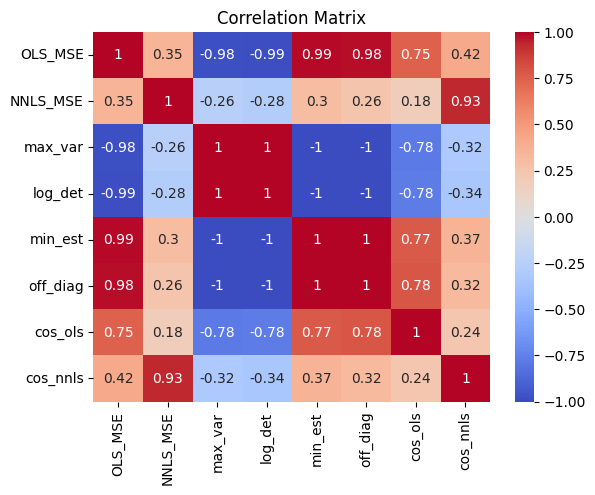

In [17]:
# Correlation heatmap
corr_matrix = A_corr[['OLS_MSE','NNLS_MSE', 'max_var', 'log_det', 'min_est', 'off_diag','cos_ols','cos_nnls']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Custom Vs

In [18]:
def generate_Vs_custom(n_tasks=16, n_parcel=32,target_corr=1):
    n_groups = 4
    group_size = 4
    variance_factors = [1.0, 0.75, 0.5, 0.25]

    # Generate base patterns with zero mean and unit variance
    base_patterns = np.random.randn(n_groups, n_parcel)
    base_patterns -= np.mean(base_patterns, axis=1, keepdims=True)
    base_patterns /= np.linalg.norm(base_patterns, axis=1, keepdims=True)

    # Orthogonalize the base patterns
    def gram_schmidt(V):
        Q = np.zeros_like(V)
        for i in range(V.shape[0]):
            q = V[i]
            for j in range(i):
                q -= np.dot(Q[j], V[i]) * Q[j]
            q_norm = np.linalg.norm(q)
            if q_norm > 1e-10:
                Q[i] = q / q_norm
            else:
                Q[i] = q
        return Q

    base_patterns = gram_schmidt(base_patterns)

    Vs = np.zeros((n_tasks, n_parcel))

    desired_corr = target_corr
    beta = np.sqrt((1 - desired_corr) / desired_corr)

    task_index = 0
    for group_index in range(n_groups):
        base_pattern = base_patterns[group_index]
        for i in range(group_size):
            variance_factor = variance_factors[i]
            # Generate a noise vector orthogonal to the base pattern
            noise = np.random.randn(n_parcel)
            noise -= np.dot(noise, base_pattern) * base_pattern  # Ensure orthogonality
            noise /= np.linalg.norm(noise)  # Normalize noise vector

            # Scale the base pattern and noise
            task_vector = variance_factor * base_pattern + beta * noise
            Vs[task_index] = task_vector
            task_index += 1

    return Vs

def add_correlated_tasks_info(df, group_size):
    """Adds the number of correlated tasks and pairs to the dataframe."""
    n_correlated_tasks_list = []
    n_correlated_pairs_list = []
    for comb in df['combination']:
        group_indices = [task_index // group_size for task_index in comb]
        from collections import Counter
        counts = Counter(group_indices)

        n_correlated_tasks = sum(count for count in counts.values() if count > 1)
        n_correlated_pairs = sum(count * (count - 1) // 2 for count in counts.values())
        n_correlated_tasks_list.append(n_correlated_tasks)
        n_correlated_pairs_list.append(n_correlated_pairs)

    df['n_correlated_tasks'] = n_correlated_tasks_list
    df['n_correlated_pairs'] = n_correlated_pairs_list
    return df

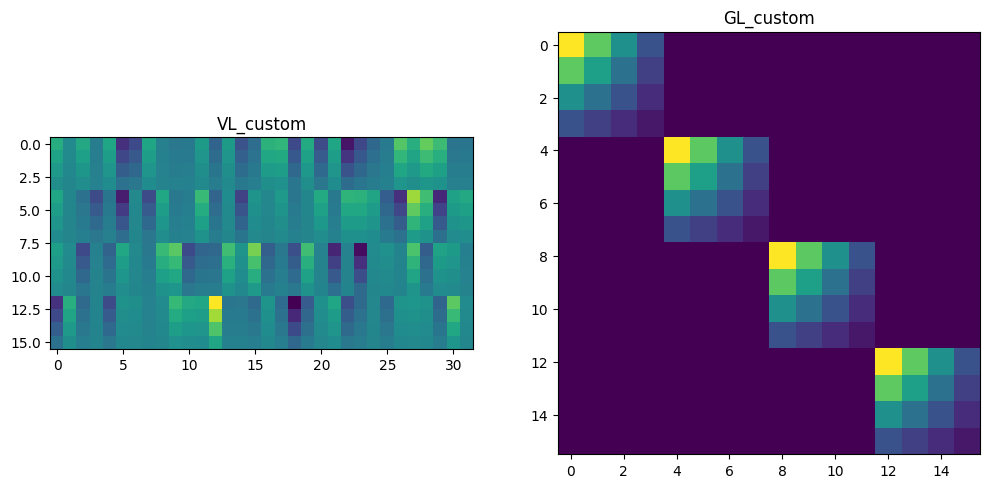

In [19]:
VL_custom = generate_Vs_custom()
G_custom = VL_custom @ VL_custom.T

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_custom)
ax[0].set_title('VL_custom')

ax[1].imshow(G_custom)
ax[1].set_title('GL_custom')

plt.show()

In [20]:
D_custom = ut.build_combinations(G_custom, strategy='random',n_iter=100,n_tasks=8,seed=1)
D_custom = evaluate_U_MSE(D_custom, VL_custom, y_test, V_test)

group_size = 4
D_custom = add_correlated_tasks_info(D_custom, group_size)

A_custom = D_custom[D_custom['offset'] == 0.001]


/tmp/ipykernel_389191/1177335138.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest)
/tmp/ipykernel_389191/1177335138.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest)


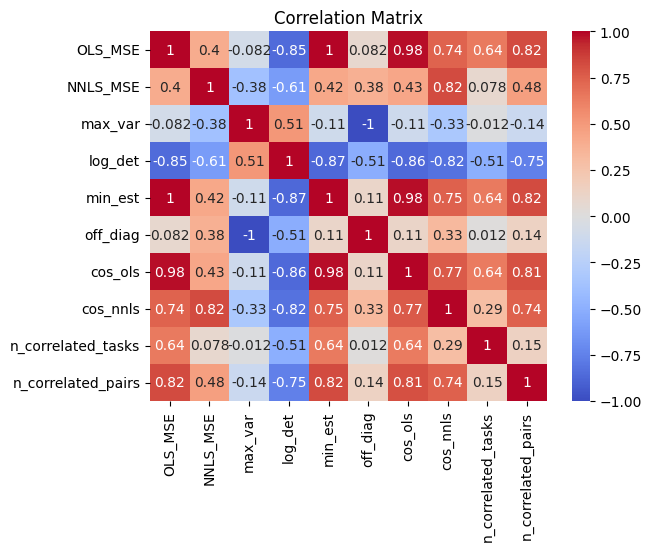

In [22]:
# Correlation heatmap
corr_matrix = A_custom[['OLS_MSE','NNLS_MSE', 'max_var', 'log_det', 'min_est', 'off_diag', 'cos_ols','cos_nnls','n_correlated_tasks','n_correlated_pairs']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



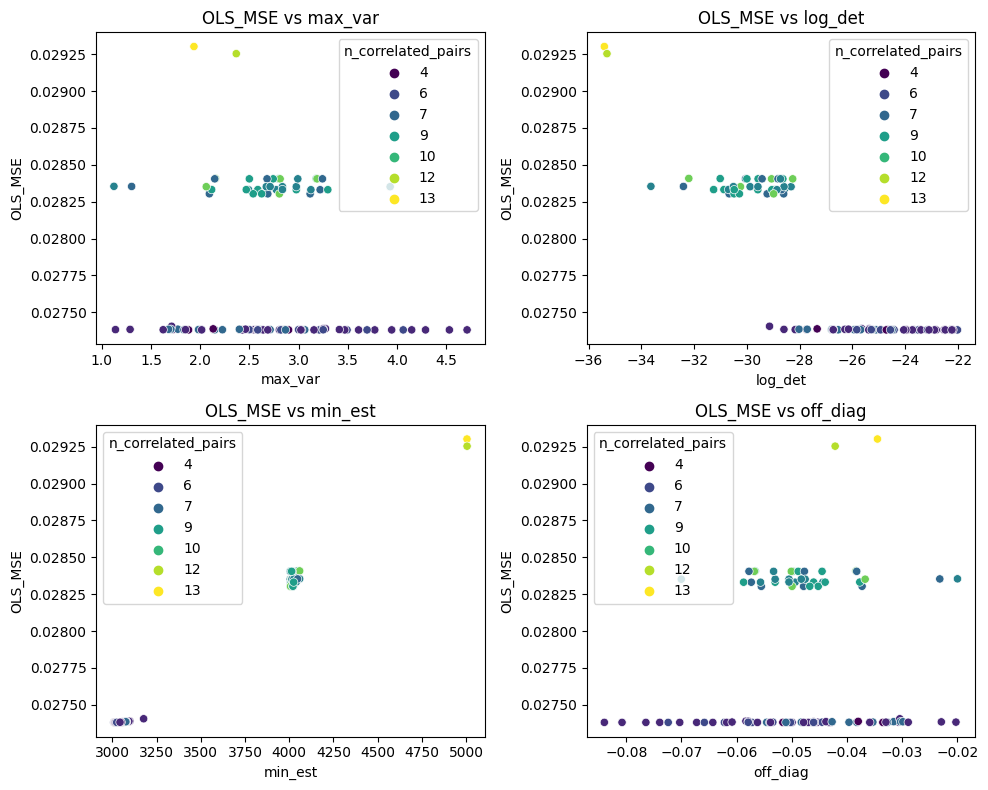

In [19]:
# Scatter plots of OLS_MSE vs eigenmetrics
metrics = ['max_var', 'log_det', 'min_est', 'off_diag']
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
for ax, metric in zip(axs.flatten(), metrics):
    sns.scatterplot(data=A_custom, x=metric, y='OLS_MSE', ax=ax, hue='n_correlated_pairs', palette='viridis')
    ax.set_title(f'OLS_MSE vs {metric}')
plt.tight_layout()
plt.show()


# MDTB Vs

In [23]:
# mdtb vs based on HBP
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models'
if not os.path.exists(model_dir):
    model_dir = '/cifs/diedrichsen/data/Cerebellum/ProbabilisticParcellationModel/Models'
    
model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
fname = model_dir + model_name
with open(fname + '.pickle', 'rb') as file:
        full_model = pickle.load(file)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

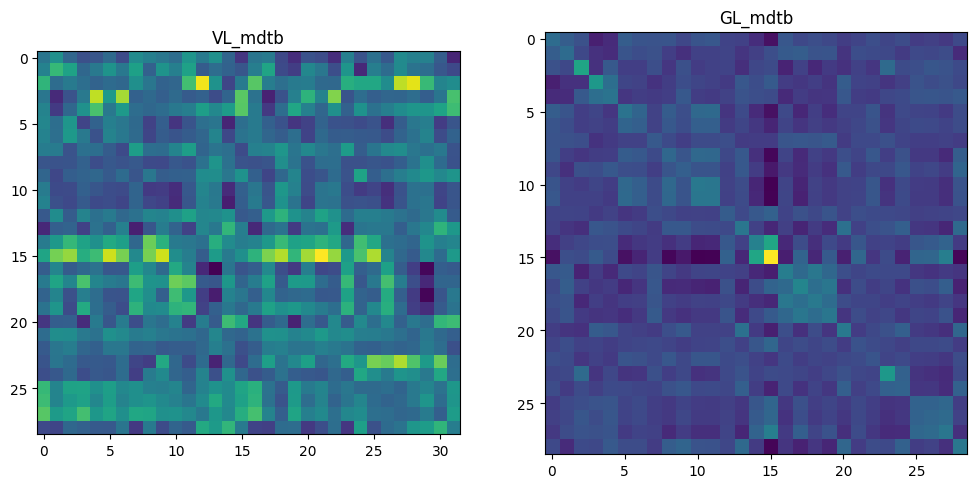

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(VL_mdtb)
ax[0].set_title('VL_mdtb')

ax[1].imshow(GL_mdtb)
ax[1].set_title('GL_mdtb')

plt.show()

In [27]:
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',n_iter=200,n_tasks=8,seed=1)
D_mdtb = evaluate_U_MSE(D_mdtb, VL_mdtb, y_test, V_test)

A_mdtb = D_mdtb[D_mdtb['offset'] == 0.001]

/tmp/ipykernel_389191/1177335138.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest = pt.tensor(ytest)
/tmp/ipykernel_389191/1177335138.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest)


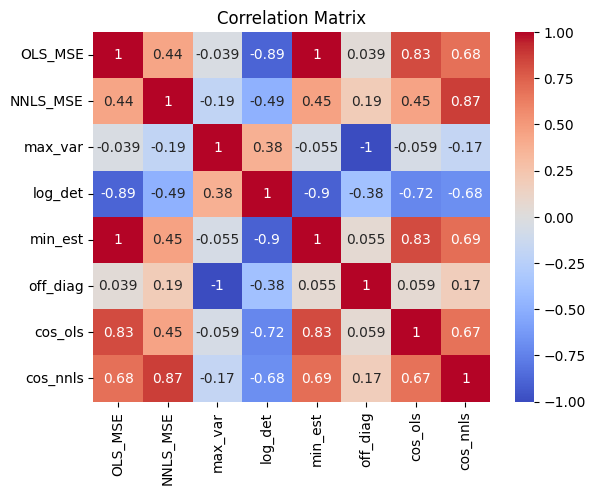

In [28]:
# Correlation heatmap
corr_matrix = A_mdtb[['OLS_MSE','NNLS_MSE', 'max_var', 'log_det', 'min_est', 'off_diag','cos_ols','cos_nnls']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
